# Análise de dados de Sistema de Monitoramento

O presente trabalho tem como objetivo analisar os dados das avaliações Formativa 1 aplicadas no programa PBA Sergipe para entender a eficácia pedagógica do programa através de seus instrumentos. No entanto, o presente relatório busca analisar somente os dados de 30 turmas provenientes de aditivo de contrato. Segue lista de código de turmas a serem analisadas aqui:

TURMA-P0000009-0002; 
TURMA-P0000135-0001; 
TURMA-P0000004-0002; 
TURMA-P0000026-0002; 
TURMA-28000013-0007; 
TURMA-28000013-0008; 
TURMA-28009398-0018; 
TURMA-28018389-0012; 
TURMA-P0000136-0001; 
TURMA-28018575-0017; 
TURMA-28023315-0010; 
TURMA-28021177-0005; 
TURMA-28029577-0010; 
TURMA-28003047-0001; 
TURMA-28020553-0001; 
TURMA-28014170-0001; 
TURMA-28014170-0002; 
TURMA-28003624-0001; 
TURMA-28003365-0005; 
TURMA-28003411-0001; 
TURMA-28003411-0002; 
TURMA-28009983-0008; 
TURMA-28009983-0009; 
TURMA-28007409-0001; 
TURMA-28029372-0003; 
TURMA-28029372-0004; 
TURMA-28007360-0003; 
TURMA-28030451-0001; 
TURMA-28003500-0007; 
TURMA-28003500-0008.


## Importando bibliotecas e dados

In [1]:
# Importando bibliotecas
import pandas as pd
import re
import matplotlib.pyplot as plt
from matplotlib import patheffects
import seaborn as sns
import os
import geopandas as gpd
import contextily as ctx
import textwrap
from statistics import mode, median, StatisticsError
import numpy as np
from scipy.stats import chi2_contingency, wilcoxon

# Importando arquivo
df_cadastro = pd.read_excel(
    'Data_files/public_data/xls_pedagogico_26092025.xlsx')
df_turmas = pd.read_excel(
    'Data_files/public_data/turmas_26092025.xlsx')
df_registros = pd.read_excel(
    'Data_files/public_data/xls_detalhado_26092025.xlsx')
df_relatorios_formativa1 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa1_26092025.xlsx')

print('df_cadastro:')
print(df_cadastro.info())
#print(df_cadastro.head())

print('df_turmas:')
print(df_turmas.info())
#print(df_turmas.head())

print('df_registros:')
print(df_registros.info())
#print(df_registros.head())

print('df_relatorios_formativa1:')
print(df_relatorios_formativa1.info())
#print(df_relatorios_formativa1.head())


df_cadastro:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4667 entries, 0 to 4666
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   CPF                        4667 non-null   object
 1   Nome                       4667 non-null   object
 2   Turma                      4667 non-null   object
 3   Data de início             4667 non-null   object
 4   Alfabetizador              4667 non-null   object
 5   Coordenador                4667 non-null   object
 6   Qtde presença              4667 non-null   int64 
 7   Qtde ausência              4667 non-null   int64 
 8   Atividade - Entrada        4643 non-null   object
 9   Atividade - Formativa 1    4601 non-null   object
 10  Atividade - Formativa 2    3942 non-null   object
 11  Atividade - Formativa 3    3445 non-null   object
 12  Atividade - Formativa 4    3130 non-null   object
 13  Atividade - Saída          2864 non-null   object


## Tratando dos dados
Se faz necessário a transformação dos dados para que seja mais fácil sua análise. De acordo com a observação dos dados apresentados, as seguintes transformações serão necessárias:
Em df_registros:
- Transformar nomes de cada coluna para o padrão snake_case;
- Extrair somente os níveis da coluna "Nível";
- Deixar os níveis de maneira categórica corretamente para melhor análise na coluna "Nível".

Em df_relatorios
- Transformar nomes de cada coluna para o padrão snake_case;
- As colunas que contém perguntas serão reduzidas somente a palavra "pergunta" seguida do seu número, exemplo: pergunta_1
- As categorias de resposta serão resumidas em no máximo 3 palavras para facilitar a interpretação - um dicionário será criado aqui.

Em df_cadastro, df_turmas, df_relatorios_(diagnostica / formativa1, 2 e 3):
- Todas as colunas que contem datas deverão ser tranformados para o tipo datetime.

In [2]:
# Transformando nomes de colunas para padrão snake_case
# Função para converter para snake_case
def to_snake_case(column_name):
    return (
        column_name
        .lower()  # Converte tudo para minúsculo
        .replace(' ', '_')  # Substitui espaços por underscore
        .replace('é', 'e')  # Remove acentos
        .replace('ã', 'a')
        .replace('ç', 'c')
        .replace('í', 'i')
        .replace('ó', 'o')
        .replace('ú', 'u')
        .replace('á', 'a')
    )

# Função para extrair o número de perguntas e renomear
def renomear_perguntas(nome_coluna):
    match = re.match(r'^(\d+)\._', nome_coluna)  # Procura o padrão "X._" no início
    if match:
        numero = match.group(1)
        return f'pergunta_{numero}'
    return nome_coluna  # Mantém o nome original se não for uma pergunta numerada

# Aplica a função to_snake_case aos nomes das colunas
df_cadastro.columns = [to_snake_case(col) for col in df_cadastro.columns]
df_turmas.columns = [to_snake_case(col) for col in df_turmas.columns]
df_registros.columns = [to_snake_case(col) for col in df_registros.columns]
df_relatorios_formativa1.columns = [to_snake_case(col) for col in df_relatorios_formativa1.columns]

# Extraindo somente os dados de nível em df_registros
df_registros['nivel'] = df_registros['nivel'].str.extract(r'(Nível [1-3])')

# Padronizando pergunta em df_relatorios_formativa1
df_relatorios_formativa1 = df_relatorios_formativa1.rename(columns={'quais_os_possiveis_entraves_ocorridos_para_o_desenvolvimento_da_turma?':'entraves_no_desenvolvimento_da_turma'})

# Ordenando nívels de maneira categórica corretamente
df_registros['nivel'] = pd.Categorical(
    df_registros['nivel'],
    categories=['Nível 1', 'Nível 2', 'Nível 3'],
    ordered=True)

# Verificando os tipos de dados e informações das colunas
#print(df_cadastro.info())
#print(df_turmas.info())
#print(df_registros.info())
#print(df_relatorios_formativa1.info())


### Extração das turmas do aditivo a serem analisadas
Antes de iniciar as análises, vamos extrair somente os dados das 30 turmas que precisamos e descartar todo o resto.

In [3]:
# Lista das turmas que você quer filtrar
turmas_selecionadas = [
    "TURMA-P0000009-0002", "TURMA-P0000135-0001", "TURMA-P0000004-0002", "TURMA-P0000026-0002",
    "TURMA-28000013-0007", "TURMA-28000013-0008", "TURMA-28009398-0018", "TURMA-28018389-0012",
    "TURMA-P0000136-0001", "TURMA-28018575-0017", "TURMA-28023315-0010", "TURMA-28021177-0005",
    "TURMA-28029577-0010", "TURMA-28003047-0001", "TURMA-28020553-0001", "TURMA-28014170-0001",
    "TURMA-28014170-0002", "TURMA-28003624-0001", "TURMA-28003365-0005", "TURMA-28003411-0001",
    "TURMA-28003411-0002", "TURMA-28009983-0008", "TURMA-28009983-0009", "TURMA-28007409-0001",
    "TURMA-28029372-0003", "TURMA-28029372-0004", "TURMA-28007360-0003", "TURMA-28030451-0001",
    "TURMA-28003500-0007", "TURMA-28003500-0008"
]

# Função para filtrar turmas
def filtrar_turmas(df, coluna_turma='turma'):
    """
    Filtra um dataframe para manter apenas as linhas com as turmas selecionadas.
    
    Parâmetros:
    df -- DataFrame a ser filtrado
    coluna_turma -- nome da coluna que contém os códigos das turmas (padrão: 'turma')
    
    Retorna:
    DataFrame filtrado apenas com as turmas selecionadas
    """
    # Verifica se a coluna existe no dataframe
    if coluna_turma not in df.columns:
        raise ValueError(f"A coluna '{coluna_turma}' não foi encontrada no DataFrame")
    
    # Filtra o dataframe
    df_filtrado = df[df[coluna_turma].isin(turmas_selecionadas)]
    
    return df_filtrado

# Aplicando função
df_cadastro = filtrar_turmas(df_cadastro, coluna_turma='turma')
df_turmas = filtrar_turmas(df_turmas, coluna_turma='turma')
df_registros = filtrar_turmas(df_registros, coluna_turma='turma')
df_relatorios_formativa1 = filtrar_turmas(df_relatorios_formativa1, coluna_turma='turma')

# Criando dfs para cada avaliação realizada
df_registros_diag = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA']
df_registros_form_1 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 1']
df_registros_form_2 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 2']
df_registros_form_3 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 3']
df_registros_form_4 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 4']
df_registros_soma = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA\n']

## Entendendo os dados
Aqui vamos entender cada coluna das tabelas e descrever cada uma delas para melhor entender os dados:

df_registros:
- cpf: representa o CPF dos alunos
- nome: representa o nome completo do aluno;
- turma: código da turma do aluno;
- municipio: nome do município da turma;
- atividade: atividade estruturada realizada;
- linguagem: práticas de linguagem de acordo com objetivos da aprendizagem localizados na matriz de referência (Oralidade e leitura; Análise Linguística; Produção de texto)
- aprendizagem: Prática avaliativa - itens analisados por nível pelo professor após a correção da atividade (varia entre atividades estruturadas)
- nivel: nível de classificação que vai de 1 a 3.

df_relatorios_diagnostica:
- alfabetizador: nome do alfabetizador responsável pela turma;
- turma: código unívoco da turma;
- data_de_lancamento: data de lançamento do relatório;
- pergunta_1: O que os motiva a voltar a estudar?
- pergunta_2: Quais as perspectivas da turma quanto a alfabetização e ao letramento?
- pergunta_3: Quanto ao interesse pelo processo de alfabetização, a turma:
- pergunta_4: A turma consegue realizar atividades propostas de forma independente?
- pergunta_5: O que a turma faz quando sente que não está entendendo alguma coisa?
- pergunta_6: Como a turma reage diante de erros ou falhas?
- pergunta_7: Como os(as) alfabetizandos(as) se comportam durante as atividades em grupo?
- pergunta_8: Quanto a leitura de palavras simples e escrita de sílabas e letras, a observação inicial é de que a turma tem:
- pergunta_9: Em relação a aplicação do conhecimento em situações prática, a turma apresenta:
- pergunta_10: Como os(as) alfabetizandos(as) valorizam o saber no seu dia a dia?

## Estudando os dados gerais: analisando o programa como um todo.
Agora vamos entender como os dados gerais estão se comportando. Os objetivos aqui são:
- Entender qual número total de alunos;
- Entender qual o número total de turmas;
- Entender qual o número médio de alunos por turma;
- Entender quantas turmas estão estudando cada unidade do livro (1, 2, 3 ou 4), no estado todo e por município.
- Entender os resultados dos alunos em cada atividade avaliativa de maneira geral, verificando os resultados e relacionando-os com a matriz de referência;
- Fazer comparativos para entender evolução dos alunos, comparando Formativas em suas devidas Práticas de Linguagem, no estado e em cada município;
- Entender se está havendo evolução ou não dos alunos. 

In [4]:
# Entendendo número total de alunos enturmados
enturmados = df_cadastro['nome'].count()

# Entendendo número de turmas totais
n_turmas = df_cadastro['turma'].nunique()

# Entendendo número médio de alunos por turma
media_alunos_por_turma = enturmados / n_turmas

# Entendendo número de turmas com registros de formativa 2
turmas_com_registros_formativa1 = df_registros['turma'].nunique()

# Impirmindo resultados
print(f"Número total de alunos estudando: {enturmados}")
print(f"Número total de turmas iniciadas: {n_turmas}")
print(f"Número médio de alunos por turma: {media_alunos_por_turma:.2f}")
print(f"Número de turmas com registros de formativa 1: {turmas_com_registros_formativa1}")


Número total de alunos estudando: 564
Número total de turmas iniciadas: 30
Número médio de alunos por turma: 18.80
Número de turmas com registros de formativa 1: 30


In [5]:
# Entendendo número de registros em cada turma para Formativa 2
contagem_por_turma = df_cadastro.groupby('turma')['atividade_-_formativa_1'].count()

# Listando turmas sem dados
sem_dados = contagem_por_turma[contagem_por_turma == 0].index.tolist()

# Imprimindo resultados
print(contagem_por_turma)
# print(sem_dados)


turma
TURMA-28000013-0007    18
TURMA-28000013-0008    14
TURMA-28003047-0001    15
TURMA-28003365-0005    12
TURMA-28003411-0001    24
TURMA-28003411-0002    14
TURMA-28003500-0007    20
TURMA-28003500-0008    12
TURMA-28003624-0001    19
TURMA-28007360-0003    20
TURMA-28007409-0001    20
TURMA-28009398-0018    20
TURMA-28009983-0008    16
TURMA-28009983-0009    19
TURMA-28014170-0001    18
TURMA-28014170-0002    13
TURMA-28018389-0012    23
TURMA-28018575-0017    10
TURMA-28020553-0001    24
TURMA-28021177-0005    23
TURMA-28023315-0010    25
TURMA-28029372-0003    20
TURMA-28029372-0004    19
TURMA-28029577-0010    12
TURMA-28030451-0001    12
TURMA-P0000004-0002    23
TURMA-P0000009-0002     0
TURMA-P0000026-0002    26
TURMA-P0000135-0001    12
TURMA-P0000136-0001    15
Name: atividade_-_formativa_1, dtype: int64


In [6]:
# Find values in cadastro that are not in registros
only_in_cadastro = set(df_cadastro['turma']) - set(df_registros['turma'])

# Find values in registros that are not in cadastro
only_in_registros = set(df_registros['turma']) - set(df_cadastro['turma'])

print("Values only in df_cadastro['turma']:", only_in_cadastro)
print("Values only in df_registros['turma']:", only_in_registros)

Values only in df_cadastro['turma']: set()
Values only in df_registros['turma']: set()


In [7]:
# Pegando a lista de municipios das turmas selecionadas
municipios_turmas = sorted(df_turmas['municipio'].unique())
print(municipios_turmas)

['ARACAJU', 'CANINDÉ DE SÃO FRANCISCO', 'CAPELA', 'CARIRA', 'ITABAIANA', 'ITABAIANINHA', 'NOSSA SENHORA DO SOCORRO', 'PORTO DA FOLHA', 'POÇO REDONDO', 'SALGADO', 'SIMÃO DIAS', 'SÃO CRISTÓVÃO']


Vamos a quantidade de turmas que estão estudando cada unidade no presente momento no programa como um todo e por município.

In [8]:
# Primeiro, vamos criar um dicionário com a ordem hierárquica das atividades
ordem_atividades = {
    'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA\n': 6,
    'ATIVIDADE ESTRUTURADA FORMATIVA 4': 5,
    'ATIVIDADE ESTRUTURADA FORMATIVA 3': 4,
    'ATIVIDADE ESTRUTURADA FORMATIVA 2': 3,
    'ATIVIDADE ESTRUTURADA FORMATIVA 1': 2,
    'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA': 1
}

# Para cada turma, encontramos a atividade mais avançada que ela realizou
turmas_atividades = df_registros.groupby('turma')['atividade'].apply(
    lambda x: max(x.unique(), key=lambda a: ordem_atividades.get(a, 0))
).reset_index()

# Agora classificamos as turmas conforme sua atividade mais avançada
ls_turmas_finalizadas = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA\n']['turma'])
ls_turmas_somativa = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 4']['turma'])
ls_turmas_unid_4 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 3']['turma'])
ls_turmas_unid_3 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 2']['turma'])
ls_turmas_unid_2 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 1']['turma'])
ls_turmas_unid_1 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA']['turma'])

# Verificação - todas as turmas devem estar em exatamente uma lista
total_turmas_classificadas = (len(ls_turmas_finalizadas) + len(ls_turmas_somativa) + len(ls_turmas_unid_4) + 
                            len(ls_turmas_unid_3) + len(ls_turmas_unid_2) + len(ls_turmas_unid_1))
print(f"Total de turmas classificadas: {total_turmas_classificadas}")
print(f"Total de turmas no dataframe: {df_registros['turma'].nunique()}")

Total de turmas classificadas: 30
Total de turmas no dataframe: 30


In [9]:
# Criamos o DataFrame base com todos os municípios únicos
turmas_por_unidade = pd.DataFrame(df_registros['municipio'].unique(), columns=['municipio'])

# Função auxiliar para contar turmas e garantir todos municípios
def contar_turmas(df, turmas, nome_coluna):
    contagem = (df[df['turma'].isin(turmas)]
               .groupby('municipio')['turma']
               .nunique()
               .reset_index()
               .rename(columns={'turma': nome_coluna}))
    
    # Fazemos o merge mantendo todos os municípios originais
    resultado = pd.merge(turmas_por_unidade, contagem, on='municipio', how='left')
    resultado[nome_coluna] = resultado[nome_coluna].fillna(0).astype('int64')
    return resultado

# Aplicamos para cada lista de turmas
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_1, 'turmas_em_unid_1')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_2, 'turmas_em_unid_2')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_3, 'turmas_em_unid_3')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_4, 'turmas_em_unid_4')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_somativa, 'turmas_em_somativa')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_finalizadas, 'turmas_finalizadas')
turmas_por_unidade = turmas_por_unidade.sort_values(by='municipio', ascending=True).reset_index(drop=True)


# Entendendo quantidade de turmas por município
turmas_por_unidade['total_turmas'] = turmas_por_unidade[['turmas_em_unid_1', 'turmas_em_unid_2', 
                                                       'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa', 'turmas_finalizadas']].sum(axis=1)

print(f'Checando total de turmas: {turmas_por_unidade['total_turmas'].sum()}')
turmas_por_unidade


Checando total de turmas: 30


,municipio,turmas_em_unid_1,turmas_em_unid_2,turmas_em_unid_3,turmas_em_unid_4,turmas_em_somativa,turmas_finalizadas,total_turmas
0,Aracaju,0,3,0,0,0,0,3
1,Canindé de São Francisco,0,3,0,0,0,0,3
2,Capela,0,2,0,0,0,0,2
3,Carira,0,1,0,0,0,0,1
4,Itabaiana,0,3,0,0,0,0,3
5,Itabaianinha,0,1,0,0,0,0,1
6,Nossa Senhora do Socorro,0,1,0,0,0,0,1
7,Porto da Folha,0,9,0,0,0,0,9
8,Poço Redondo,1,0,0,0,0,0,1
9,Salgado,0,1,0,0,0,0,1


/tmp/ipykernel_64809/2448121913.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=turmas_por_unidade.sort_values('total_turmas', ascending=False),


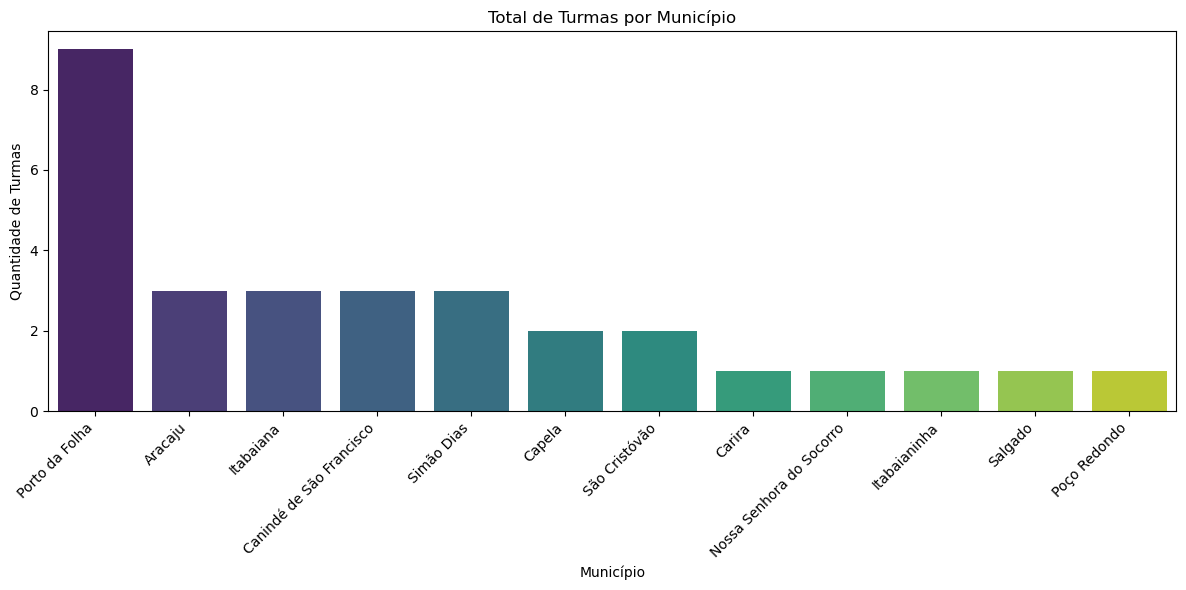

In [10]:
# Criando diretório para salvar os gráficos
output_dir_relatorio_21 = "Data_files/graficos_relatorio_2.1_turmas_aditivo"
os.makedirs(output_dir_relatorio_21, exist_ok=True)

# Criando gráfico de total de turmas por município
plt.figure(figsize=(12, 6))
sns.barplot(data=turmas_por_unidade.sort_values('total_turmas', ascending=False),
            x='municipio', y='total_turmas', palette='viridis')
plt.title('Total de Turmas por Município')
plt.xlabel('Município')
plt.ylabel('Quantidade de Turmas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{output_dir_relatorio_21}/total_por_municipio.png', dpi=300)
plt.show()

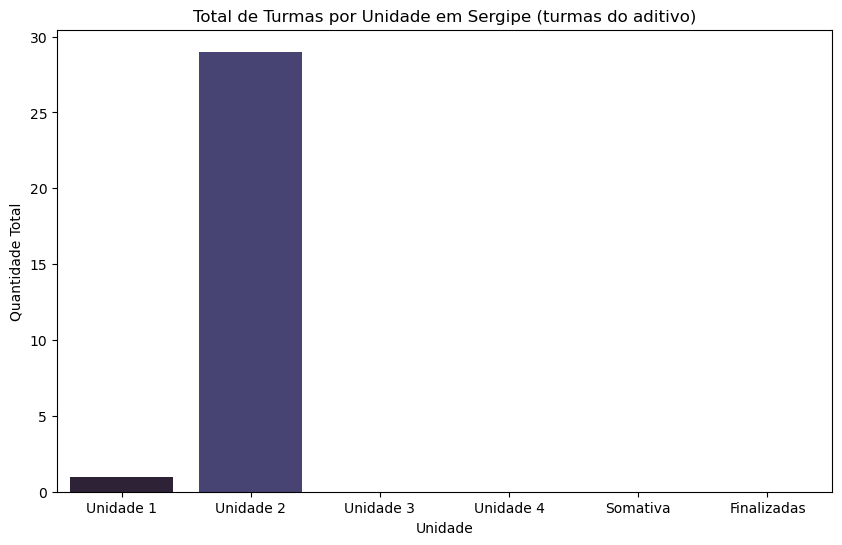

In [11]:
# Criando gráfico de total de turmas em cada unidade
# Gráfico 2: Total de turmas por unidade (com rótulos personalizados)
df_unidades = turmas_por_unidade.melt(
    id_vars=['municipio'],
    value_vars=['turmas_em_unid_1', 'turmas_em_unid_2', 'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa', 'turmas_finalizadas'],
    var_name='Unidade',
    value_name='Quantidade'
)

# Mapear nomes das unidades
mapeamento_unidades = {
    'turmas_em_unid_1': 'Unidade 1',
    'turmas_em_unid_2': 'Unidade 2',
    'turmas_em_unid_3': 'Unidade 3',
    'turmas_em_unid_4': 'Unidade 4',
    'turmas_em_somativa': 'Somativa',
    'turmas_finalizadas': 'Finalizadas'
}
df_unidades['Unidade'] = df_unidades['Unidade'].map(mapeamento_unidades)

# Plotar o gráfico (sem warnings!)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_unidades,
    x='Unidade',
    y='Quantidade',
    hue='Unidade',      # Adicionado para evitar o warning
    estimator=sum,
    errorbar=None,
    palette='mako',
    legend=False        # Remove legenda redundante
)
plt.title('Total de Turmas por Unidade em Sergipe (turmas do aditivo)')
plt.xlabel('Unidade')
plt.ylabel('Quantidade Total')
plt.savefig(f'{output_dir_relatorio_21}/total_turmas_por_unidade_sergipe.png', dpi=300)
#plt.close()
plt.show()

In [12]:
# Criando um gráfico por município para mostrar número de turmas em cada unidade
# Criar um gráfico para cada município
for municipio in turmas_por_unidade['municipio'].unique():
    # Filtrar dados do município
    df_municipio = turmas_por_unidade[turmas_por_unidade['municipio'] == municipio]
    
    # Transformar os dados para formato longo (melt) e aplicar mapeamento
    df_melted = df_municipio.melt(
        id_vars=['municipio'], 
        value_vars=['turmas_em_unid_1', 'turmas_em_unid_2', 'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa', 'turmas_finalizadas'],
        var_name='Unidade', 
        value_name='Quantidade'
    )
    
    # Aplicar os novos nomes das unidades
    df_melted['Unidade'] = df_melted['Unidade'].map(mapeamento_unidades)
    
    # Ordenar as unidades
    df_melted['Unidade'] = pd.Categorical(
        df_melted['Unidade'],
        categories=['Unidade 1', 'Unidade 2', 'Unidade 3', 'Unidade 4', 'Somativa', 'Finalizadas'],
        ordered=True
    )
    
    # Configurar o gráfico (versão atualizada do Seaborn)
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=df_melted,
        x='Unidade',
        y='Quantidade',
        hue='Unidade',  # Adicionado para evitar o warning
        palette='rocket',
        legend=False    # Não mostra a legenda redundante
    )
    
    # Adicionar título e rótulos
    plt.title(f'Distribuição de Turmas do Aditivo em {municipio}')
    plt.xlabel('Unidade')
    plt.ylabel('Quantidade de Turmas')
    
    # Salvar o gráfico
    nome_arquivo = f"turmas_por_unidade_{municipio.lower().replace(' ', '_').replace('ã', 'a').replace('ç', 'c')}_aditivo.png"
    plt.tight_layout()
    plt.savefig(f'{output_dir_relatorio_21}/{nome_arquivo}', dpi=300)
    plt.close()


##### Estudando os dados por município
Agora vamos entender os dados de cada município. Dessa forma, nosso objetivo aqui é:
- Entender a quantidade de alunos por município e sua proporção em relação ao programa como um todo;
- Entender a quantidade de turmas por município e sua proporção em relação ao programa como um todo;
- Entender a relevância dos alunos perante o total de alunos enturmados em Sergipe;
- Gerar os resultados dos registros por atividade estruturada por município;
- Gerar os resultados de perfil de turma por município e entender se os perfis são diferentes.

##### Entendendo alunos e turmas por município


#### Atividade Estruturada Formativa 1

Primeiramente, vamos construir uma tabela contando as quantidades de cada nível para cada formativa, considerando a linguagem, municipio e a turma.

In [13]:
# Calculando moda dos níveis para cada linguagem
def calcular_moda_nivel(df, form_number):
    """
    Calcula a moda da coluna 'nivel' para um dataframe de formulário específico.
    
    Args:
        df: DataFrame com os registros do formulário
        form_number: Número do formulário (1, 2, 3, 4 ou 5 para somativa)
    
    Returns:
        DataFrame com as modas calculadas
    """
    moda_df = (
        df.groupby(['cpf', 'nome', 'turma', 'municipio', 'linguagem'])['nivel']
        .agg(lambda x: x.mode().iloc[0])
        .reset_index()
    )
    return moda_df

# Calcular modas para cada formulário
moda_form_1 = calcular_moda_nivel(df_registros_form_1, 1)
moda_form_2 = calcular_moda_nivel(df_registros_form_2, 2)
moda_form_3 = calcular_moda_nivel(df_registros_form_3, 3)
moda_form_4 = calcular_moda_nivel(df_registros_form_4, 4)
moda_somativa = calcular_moda_nivel(df_registros_soma, 5)

moda_form_1.head()

,cpf,nome,turma,municipio,linguagem,nivel
0,014.286.957-02,Enzo da Cunha,TURMA-28029577-0010,Itabaianinha,Análise linguística,Nível 2
1,014.286.957-02,Enzo da Cunha,TURMA-28029577-0010,Itabaianinha,Oralidade e leitura,Nível 2
2,016.234.875-44,Felipe Dias,TURMA-28003365-0005,Porto da Folha,Análise linguística,Nível 3
3,016.234.875-44,Felipe Dias,TURMA-28003365-0005,Porto da Folha,Oralidade e leitura,Nível 3
4,016.327.459-25,Dra. Maya Marques,TURMA-28029372-0004,Porto da Folha,Análise linguística,Nível 2


In [14]:
# Contando níveis por formativa
def contar_niveis_por_form(df, form_number):
    # Conta a ocorrência de cada nível, mantendo as colunas de agrupamento
    # Adicionando observed=True para evitar o warning
    contagem = (
        df.groupby(['turma', 'municipio', 'linguagem', 'nivel'], observed=True)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    
    # Renomeia as colunas de nível para incluir o número do formulário
    nivel_cols = [col for col in contagem.columns if col not in ['turma', 'municipio', 'linguagem']]
    rename_dict = {col: f'form_{form_number}_{col}' for col in nivel_cols}
    contagem = contagem.rename(columns=rename_dict)
    
    return contagem

# Aplicar a função para cada formulário
contagem_form_1 = contar_niveis_por_form(moda_form_1, 1)
contagem_form_2 = contar_niveis_por_form(moda_form_2, 2)
contagem_form_3 = contar_niveis_por_form(moda_form_3, 3)
contagem_form_4 = contar_niveis_por_form(moda_form_4, 4)
contagem_somativa = contar_niveis_por_form(moda_somativa, 'somativa')  

contagem_form_1.head()
        

nivel,turma,municipio,linguagem,form_1_Nível 1,form_1_Nível 2,form_1_Nível 3
0,TURMA-28000013-0007,Canindé de São Francisco,Análise linguística,10,9,0
1,TURMA-28000013-0007,Canindé de São Francisco,Oralidade e leitura,10,9,0
2,TURMA-28000013-0008,Canindé de São Francisco,Análise linguística,6,9,0
3,TURMA-28000013-0008,Canindé de São Francisco,Oralidade e leitura,6,9,0
4,TURMA-28003047-0001,Porto da Folha,Análise linguística,4,4,7


Gráfico salvo: Data_files/graficos_relatorio_2.1_turmas_aditivo/grafico_oralidade_leitura.png
Gráfico salvo: Data_files/graficos_relatorio_2.1_turmas_aditivo/grafico_analise_linguistica.png

Todos os gráficos foram salvos no diretório: Data_files/graficos_relatorio_2.1_turmas_aditivo


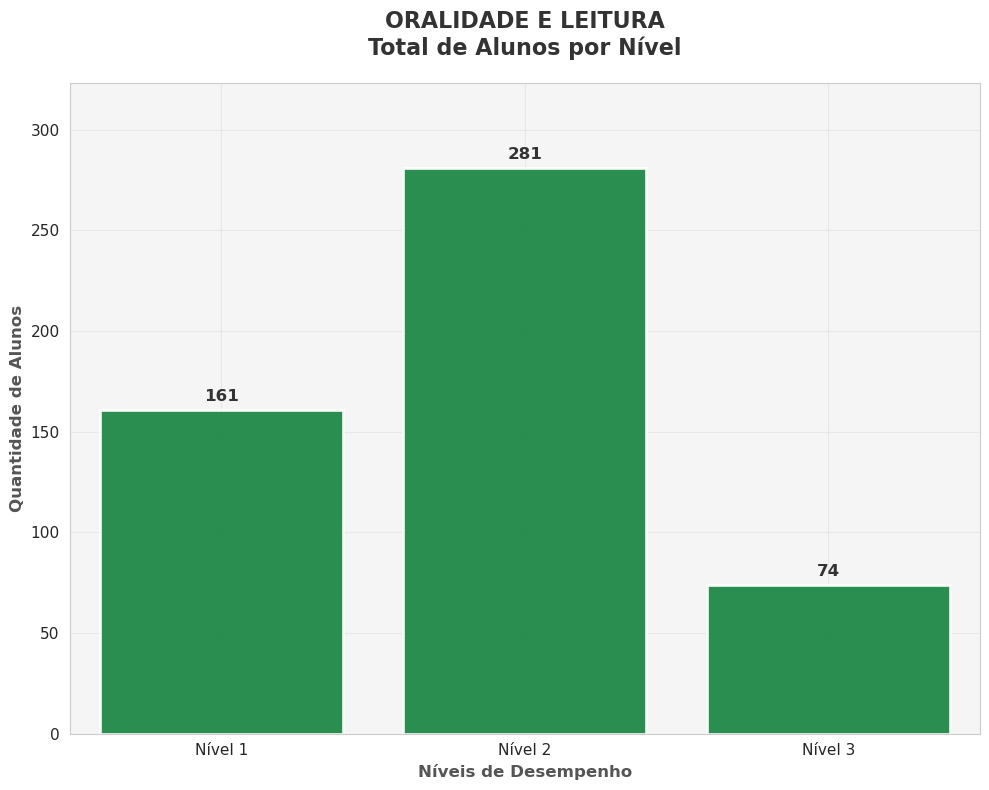

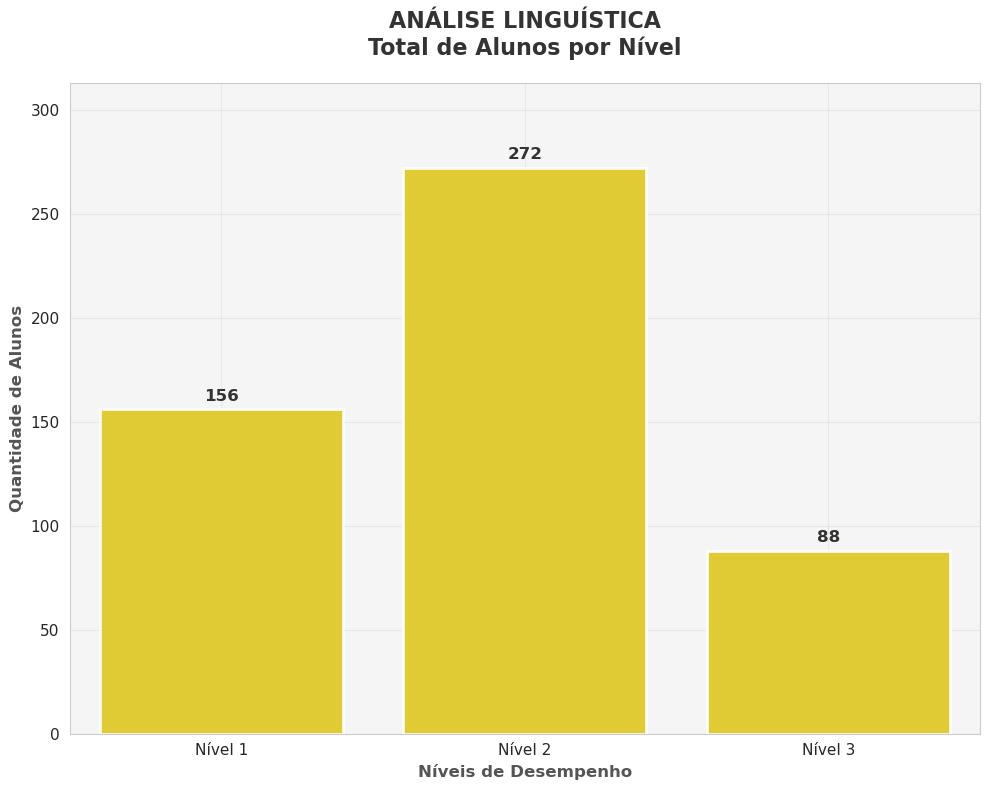

In [15]:
# Configuração do estilo com tema elegante usando cores de Sergipe
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

# Cores da bandeira de Sergipe
verde_sergipe = '#009639'  # Verde oficial
amarelo_sergipe = '#FEDF00'  # Amarelo oficial
cinza_claro = '#f5f5f5'
cinza_fundo = '#fafafa'

# Função para criar e salvar gráficos individuais
def criar_grafico_linguagem(linguagem, cor, filename):
    """Cria e salva gráfico para uma linguagem específica"""
    
    # Filtrar e somar os dados
    dados_filtrados = contagem_form_1[contagem_form_1['linguagem'] == linguagem]
    soma_niveis = dados_filtrados[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum()
    
    # Criar DataFrame para o gráfico
    df_grafico = pd.DataFrame({
        'Nível': ['Nível 1', 'Nível 2', 'Nível 3'],
        'Quantidade': soma_niveis.values
    })
    
    # Criar figura
    plt.figure(figsize=(10, 8))
    ax = plt.gca()
    
    # Criar gráfico de barras
    bars = sns.barplot(
        data=df_grafico,
        x='Nível',
        y='Quantidade',
        color=cor,
        edgecolor='white',
        linewidth=2,
        alpha=0.9
    )
    
    # Personalizar título e labels
    titulo = 'ORALIDADE E LEITURA' if linguagem == 'Oralidade e leitura' else 'ANÁLISE LINGUÍSTICA'
    plt.title(f'{titulo}\nTotal de Alunos por Nível', 
              fontsize=16, fontweight='bold', pad=20, color='#333333')
    plt.xlabel('Níveis de Desempenho', fontsize=12, fontweight='bold', color='#555555')
    plt.ylabel('Quantidade de Alunos', fontsize=12, fontweight='bold', color='#555555')
    
    # Personalizar eixos
    ax.set_facecolor(cinza_claro)
    ax.tick_params(axis='both', which='major', labelsize=11)
    
    # Adicionar valores nas barras
    max_val = df_grafico['Quantidade'].max()
    for i, valor in enumerate(df_grafico['Quantidade']):
        plt.text(i, valor + max_val * 0.01, f'{valor}', 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333')
    
    # Ajustar limite do eixo Y
    plt.ylim(0, max_val * 1.15)
    
    # Adicionar grid sutil
    plt.grid(True, alpha=0.3)
    
    # Ajustar layout
    plt.tight_layout()
    
    # Salvar gráfico
    caminho_completo = os.path.join(output_dir_relatorio_21, filename)
    plt.savefig(caminho_completo, dpi=300, bbox_inches='tight', facecolor='white')
        
    print(f"Gráfico salvo: {caminho_completo}")

# Criar e salvar gráfico para Oralidade e leitura (verde)
criar_grafico_linguagem(
    linguagem='Oralidade e leitura',
    cor=verde_sergipe,
    filename='grafico_oralidade_leitura.png'
)

# Criar e salvar gráfico para Análise linguística (amarelo)
criar_grafico_linguagem(
    linguagem='Análise linguística',
    cor=amarelo_sergipe,
    filename='grafico_analise_linguistica.png'
)

print(f"\nTodos os gráficos foram salvos no diretório: {output_dir_relatorio_21}")
plt.show()
plt.close()

In [16]:
# Configuração do estilo
sns.set_style("white")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titleweight'] = 'bold'

# Lista de municípios únicos
municipios = contagem_form_1['municipio'].unique()

# Função para criar gráfico por município e linguagem
def criar_grafico_municipio_linguagem(municipio, linguagem, cor):
    """Cria gráfico para um município e linguagem específicos"""
    
    # Filtrar dados
    dados_filtrados = contagem_form_1[
        (contagem_form_1['municipio'] == municipio) & 
        (contagem_form_1['linguagem'] == linguagem)
    ]
    
    if dados_filtrados.empty:
        return
    
    # Somar os níveis (pode haver múltiplas turmas no mesmo município)
    soma_niveis = dados_filtrados[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum()
    
    # Criar figura
    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('white')
    
    # Criar gráfico de barras
    bars = ax.bar(['NÍVEL 1', 'NÍVEL 2', 'NÍVEL 3'], soma_niveis.values,
                 color=cor, alpha=0.85, edgecolor='white', linewidth=2.5)
    
    # Configurações do gráfico
    ax.set_facecolor(cinza_fundo)
    
    # Título baseado na linguagem
    if linguagem == 'Oralidade e leitura':
        titulo = f'ORALIDADE E LEITURA\n{municipio.upper()}'
        filename = f'oralidade_{municipio.lower().replace(" ", "_")}.png'
    else:
        titulo = f'ANÁLISE LINGUÍSTICA\n{municipio.upper()}'
        filename = f'analise_{municipio.lower().replace(" ", "_")}.png'
    
    ax.set_title(titulo, fontsize=16, pad=20, color='#2d2d2d')
    ax.set_ylabel('QUANTIDADE DE ALUNOS', fontsize=12, color='#555555')
    ax.set_xlabel('NÍVEIS DE DESEMPENHO', fontsize=12, color='#555555')
    
    # Estilizar eixos
    ax.tick_params(axis='x', labelsize=11, labelcolor='#444444')
    ax.tick_params(axis='y', labelsize=10, labelcolor='#666666')
    
    # Remover bordas desnecessárias
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color('#dddddd')
    
    # Adicionar valores nas barras
    max_val = max(soma_niveis.values) if max(soma_niveis.values) > 0 else 1
    for i, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0:  # Só adiciona texto se houver valor
            ax.text(bar.get_x() + bar.get_width()/2., height + max_val*0.02,
                   f'{int(height)}', ha='center', va='bottom', 
                   fontsize=11, fontweight='bold', color='#2d2d2d')
    
    # Grid sutil
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    
    # Ajustar limite do eixo Y
    ax.set_ylim(0, max_val * 1.15)
    
    # Layout
    plt.tight_layout()
    
    # Salvar gráfico
    caminho_completo = os.path.join(output_dir_relatorio_21, filename)
    plt.savefig(caminho_completo, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    
    return filename

# Criar gráficos para todos os municípios
graficos_criados = []

for municipio in municipios:
    print(f"💾 Criando gráficos para: {municipio}")
    
    # Gráfico de Oralidade e leitura
    arquivo_oralidade = criar_grafico_municipio_linguagem(
        municipio, 'Oralidade e leitura', verde_sergipe
    )
    if arquivo_oralidade:
        graficos_criados.append(arquivo_oralidade)
    
    # Gráfico de Análise linguística
    arquivo_analise = criar_grafico_municipio_linguagem(
        municipio, 'Análise linguística', amarelo_sergipe
    )
    if arquivo_analise:
        graficos_criados.append(arquivo_analise)

# Relatório final
print(f"\n✅ Processo concluído!")
print(f"📁 Diretório: {output_dir_relatorio_21}")
print(f"📊 Total de gráficos criados: {len(graficos_criados)}")
print(f"🏙️  Municípios processados: {len(municipios)}")

💾 Criando gráficos para: Canindé de São Francisco
💾 Criando gráficos para: Porto da Folha
💾 Criando gráficos para: Carira
💾 Criando gráficos para: Itabaiana
💾 Criando gráficos para: Simão Dias
💾 Criando gráficos para: Capela
💾 Criando gráficos para: Aracaju
💾 Criando gráficos para: Nossa Senhora do Socorro
💾 Criando gráficos para: São Cristóvão
💾 Criando gráficos para: Salgado
💾 Criando gráficos para: Itabaianinha

✅ Processo concluído!
📁 Diretório: Data_files/graficos_relatorio_2.1_turmas_aditivo
📊 Total de gráficos criados: 22
🏙️  Municípios processados: 11


In [17]:
df_unidades = df_unidades.sort_values(by='municipio', ascending=True).reset_index(drop=True)
df_unidades.to_excel(f'{output_dir_relatorio_21}/turmas_por_unidade_sergipe_aditivo.xlsx', index=False)

In [18]:
# contagem_form_1.to_excel(f'{output_dir_relatorio_21}/contagem_niveis_formativa1_aditivo.xlsx', index=False)
contagem_municipios_form_1 = contagem_form_1.groupby(['municipio', 'linguagem'])[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum().reset_index()
contagem_municipios_form_1.to_excel(f'{output_dir_relatorio_21}/contagem_niveis_formativa1_por_municipio_aditivo.xlsx', index=False)